In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
health_df = pd.read_csv('/content/healthcare_dataset.csv')

In [ ]:
# shape of the dataset
shape = health_df.shape
print(shape)  # The shape represents rows,columns

(6000, 7)


In [ ]:
# column types
datatypes = health_df.dtypes
print(datatypes)  #printing the data types of columns

patient_id                   int64
age                          int64
bmi                        float64
exercise_hours_per_week    float64
smoker                       int64
blood_pressure             float64
diabetes                     int64
dtype: object


In [ ]:
null_values = health_df.isnull().sum()
print(null_values) # printts the sum of count of null values for each column in the dataset.


patient_id                 0
age                        0
bmi                        0
exercise_hours_per_week    0
smoker                     0
blood_pressure             0
diabetes                   0
dtype: int64


In [ ]:
health_df.describe()
#mean,,min,max(age,bmi,exercise_hours_per_week,blood_pressure)

,patient_id,age,bmi,exercise_hours_per_week,smoker,blood_pressure,diabetes
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,3000.500000,51.107333,25.995267,3.012800,0.307000,134.239733,0.090333
std,1732.195139,19.522722,4.960541,1.491802,0.461288,11.234260,0.286683
min,1.000000,18.000000,15.000000,0.000000,0.000000,94.000000,0.000000
25%,1500.750000,34.000000,22.500000,2.000000,0.000000,126.000000,0.000000
50%,3000.500000,51.000000,26.100000,3.000000,0.000000,134.200000,0.000000
75%,4500.250000,68.000000,29.400000,4.000000,1.000000,142.325000,0.000000
max,6000.000000,84.000000,44.900000,8.500000,1.000000,169.700000,1.000000


In [ ]:
# number of smokers vs non-smokers
smoking_status = health_df['smoker'].value_counts()
print("No of Non smokers : ", smoking_status[0])
print("No of smokers : ", smoking_status[1])


No of Non smokers :  4158
No of smokers :  1842


In [ ]:
# no of smokers who have diabetes
no_of_smokers_with_diabetes = health_df[(health_df['smoker']==1) & (health_df['diabetes']==1)]
print("Number of smokers with diabetes:", len(no_of_smokers_with_diabetes))

Number of smokers with diabetes: 161


In [ ]:
no_of_non_smokers_with_diabetes = health_df[(health_df['smoker']==0) & (health_df['diabetes']==1)]
print("Number of non-smokers with diabetes:", len(no_of_non_smokers_with_diabetes))

Number of non-smokers with diabetes: 381


In the dataset there are more number of non smokers with diabetes when compared to smokers with diabetes
i.e percentage of patients who doesnt smoke but are diabetic is higher than percentgae of patients who smoke

In [ ]:
health_df.head(2)

,patient_id,age,bmi,exercise_hours_per_week,smoker,blood_pressure,diabetes
0,1,31,18.3,1.5,0,119.1,0
1,2,44,26.3,3.1,0,120.5,0


In [ ]:
avg_age_of_smokers = health_df[health_df['smoker']==1]['age'].mean()
print("Average age of smokers:", avg_age_of_smokers)

# Average age of smokers is

Average age of smokers: 51.517372421281216


In [ ]:
avg_bp_of_smokers = health_df[health_df['smoker']==1]['blood_pressure'].mean()
print("Average blood pressure of smokers:", avg_bp_of_smokers)

# Average blood pressure of smokers

Average blood pressure of smokers: 141.44174809989144


In [ ]:
avg_bp_of_non_smokers = health_df[health_df['smoker']==0]['blood_pressure'].mean()
print("Average blood pressure of non-smokers:", avg_bp_of_non_smokers)

# Average blood pressure of non-smokers

Average blood pressure of non-smokers: 131.0492303992304


In [ ]:
# most frequently occuring age
freq_age = health_df['age'].mode()
print(freq_age)

0    32
Name: age, dtype: int64


### Age Distribution vs. Diabetes Status

Let's visualize the relationship between 'age' and 'diabetes' using a box plot to see if there's a noticeable difference in age distributions between diabetic and non-diabetic individuals.

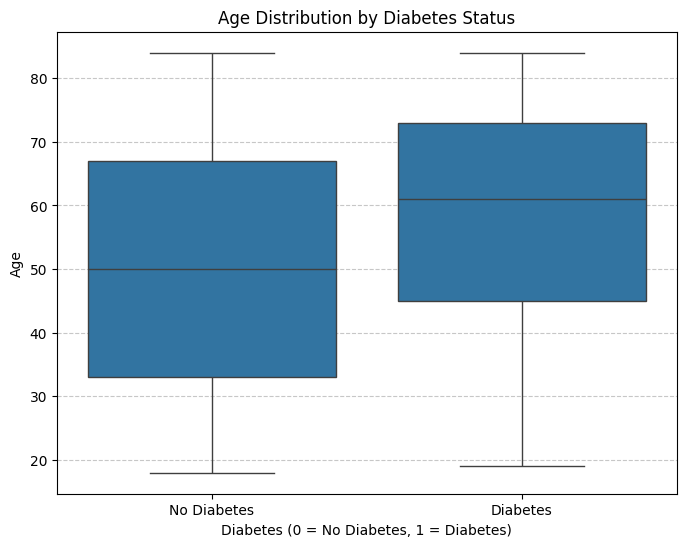

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='diabetes', y='age', data=health_df)
plt.title('Age Distribution by Diabetes Status')
plt.xlabel('Diabetes (0 = No Diabetes, 1 = Diabetes)')
plt.ylabel('Age')
plt.xticks([0, 1], ['No Diabetes', 'Diabetes'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### BMI Distribution

distribution of Body Mass Index (BMI) in the dataset.

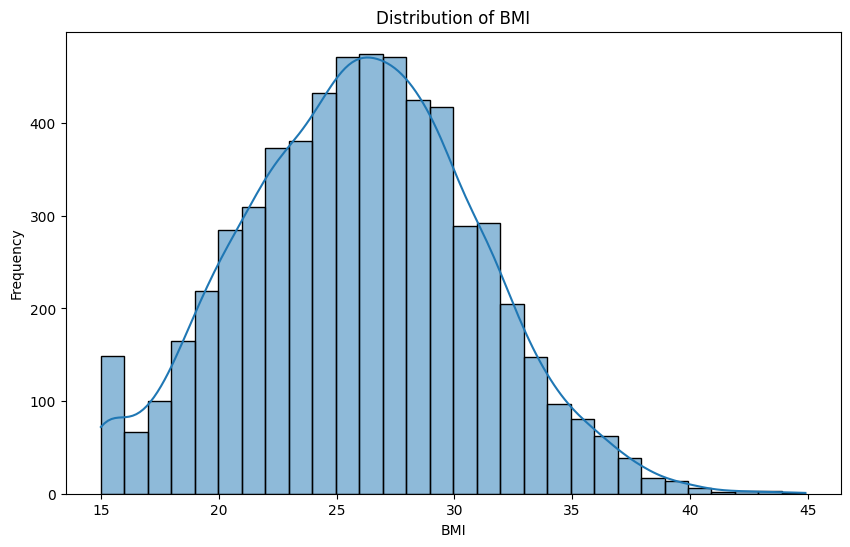

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(health_df['bmi'], kde=True, bins=30)
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()

In [ ]:
print("Mean BMI:", health_df['bmi'].mean())
print("Median BMI:", health_df['bmi'].median())
print("Mode BMI:", health_df['bmi'].mode())
print("Mean BMI:", health_df['bmi'].skew())

Mean BMI: 25.995266666666662
Median BMI: 26.1
Mode BMI: 0    15.0
Name: bmi, dtype: float64
Mean BMI: 0.07043543679254884


### Correlation Heatmap

Let's visualize the correlation between the numerical features in the dataset using a heatmap. This will help us understand which variables move together and in what direction (positive or negative correlation).

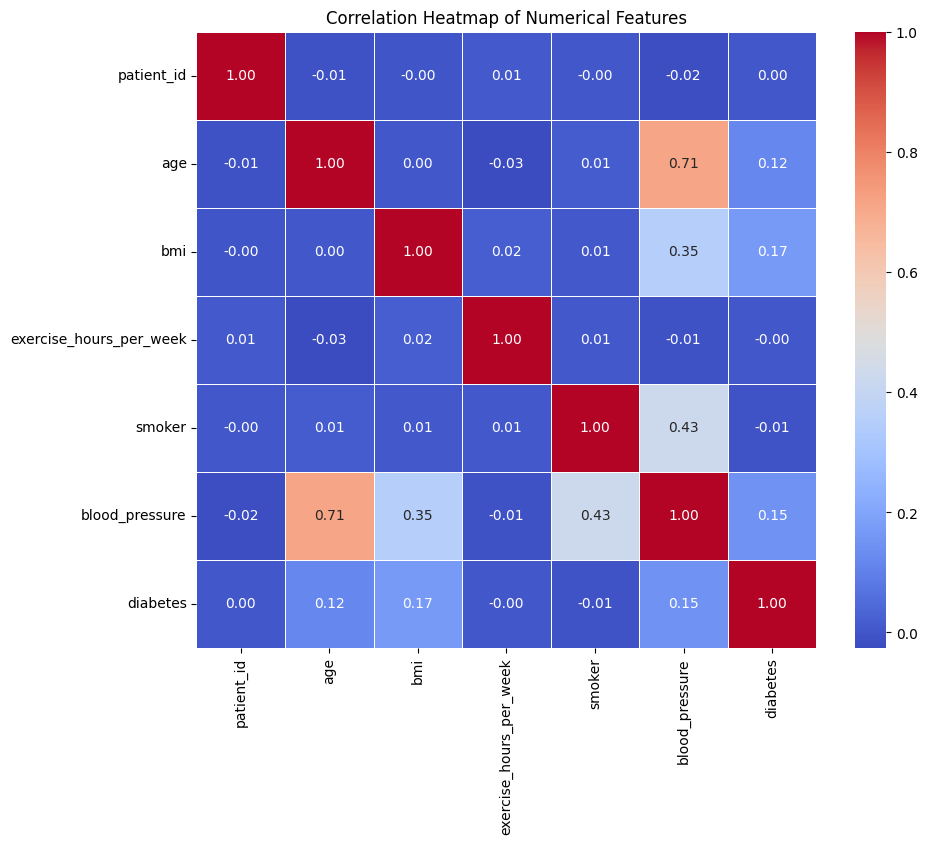

In [ ]:
# Select only numerical columns for correlation calculation
numerical_cols = health_df.select_dtypes(include=['number']).columns
correlation_matrix = health_df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

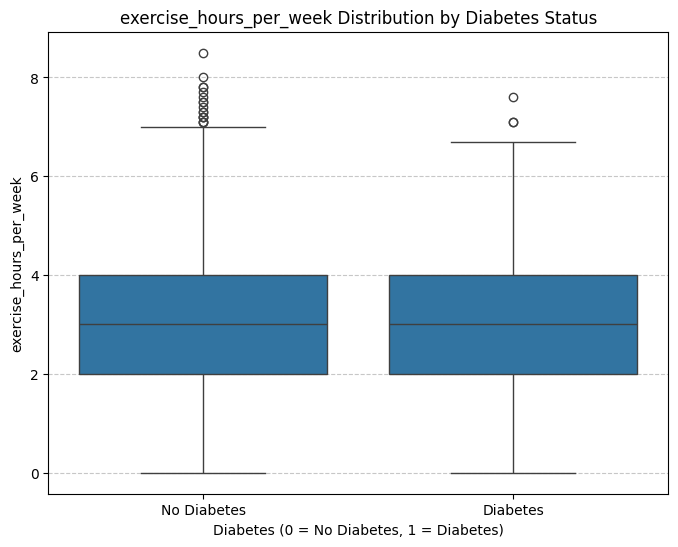

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='diabetes', y='exercise_hours_per_week', data=health_df)
plt.title('exercise_hours_per_week Distribution by Diabetes Status')
plt.xlabel('Diabetes (0 = No Diabetes, 1 = Diabetes)')
plt.ylabel('exercise_hours_per_week')
plt.xticks([0, 1], ['No Diabetes', 'Diabetes'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Logistic Regression for Diabetes Prediction

Let's build a logistic regression model to predict diabetes based on other features in the dataset.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,f1_score,precision_score,recall_score


# Drop 'patient_id' as it's an identifier and 'diabetes' as it's the target
X = health_df.drop(['patient_id', 'diabetes'], axis=1)
y = health_df['diabetes']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

Training features shape: (4800, 5)
Testing features shape: (1200, 5)
Training target shape: (4800,)
Testing target shape: (1200,)


In [ ]:
# train the Logistic Regression model
model = LogisticRegression(max_iter=500, random_state=42)
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred) # Renamed to 'f1' to avoid name collision
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", class_report)

Accuracy: 0.9092
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000

Confusion Matrix:
 [[1091    0]
 [ 109    0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      1.00      0.95      1091
           1       0.00      0.00      0.00       109

    accuracy                           0.91      1200
   macro avg       0.45      0.50      0.48      1200
weighted avg       0.83      0.91      0.87      1200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

Confusion Matrix:
 [[1091    0]
 [ 109    0]]  this represents that out of test data 1091 non- diabetic patients were correctly predicted
 and 109 patients who are diabetic are predicted as non diabetic.

### Feature Importance from Logistic Regression

For logistic regression, feature importance can be inferred from the absolute values of the coefficients. A higher absolute coefficient value suggests a stronger influence of that feature on the probability of the target variable.

In [ ]:
import pandas as pd

# Get feature names from the training data
feature_names = X_train.columns

# Get the coefficients from the trained model
coefficients = model.coef_[0]

# Create a DataFrame to display feature importance
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,                    #coefficients represents the impact of features on the target varaible. They are only available after the model training
    'Coefficient': coefficients
})

In [ ]:
feature_importance_df

,Feature,Coefficient
0,age,0.015180
1,bmi,0.113137
2,exercise_hours_per_week,0.010661
3,smoker,-0.176527
4,blood_pressure,0.012912


from the coefficients we can come to a conclusion that BMI, smoker features have much impact on is_diabetic column.

**Sequential neural network**

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
nn_model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],),name = 'Input'),
    layers.Dense(32,activation='relu',name = 'hidden_layer_1'),
    layers.Dense(16,activation='relu',name = 'hidden_layer_2'),
    layers.Dense(8,activation='relu',name = 'hidden_layer_3'),
    layers.Dense(1,activation='sigmoid',name = 'output')

])

In [ ]:
nn_model.compile(
    optimizer = 'adam',
    loss = keras.losses.BinaryCrossentropy(name = 'binary_cross_entropy'),
    metrics = [
        keras.metrics.BinaryAccuracy(name = 'accuracy'),
        keras.metrics.MeanSquaredError(name = 'MSE'),
        keras.metrics.Recall(name = 'recall')
    ]
)

In [ ]:
nn_model.fit(X_train,y_train,epochs=100,validation_data=(X_test,y_test))

Epoch 1/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - MSE: 0.0842 - accuracy: 0.9098 - loss: 0.3506 - recall: 0.0000e+00 - val_MSE: 0.0836 - val_accuracy: 0.9092 - val_loss: 0.3104 - val_recall: 0.0000e+00
Epoch 2/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - MSE: 0.0830 - accuracy: 0.9098 - loss: 0.3070 - recall: 0.0000e+00 - val_MSE: 0.0818 - val_accuracy: 0.9092 - val_loss: 0.2989 - val_recall: 0.0000e+00
Epoch 3/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - MSE: 0.0828 - accuracy: 0.9098 - loss: 0.3067 - recall: 0.0000e+00 - val_MSE: 0.0818 - val_accuracy: 0.9092 - val_loss: 0.2985 - val_recall: 0.0000e+00
Epoch 4/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - MSE: 0.0821 - accuracy: 0.9098 - loss: 0.3013 - recall: 0.0000e+00 - val_MSE: 0.0814 - val_accuracy: 0.9092 - val_loss: 0.2954 - val_recall: 0.0000e+00
Epoch 5/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - MSE: 0.0822 - accuracy: 0.9098 - loss: 0.3021 - recall: 0.0000e+00 - val_MSE: 0.0823 - val_accuracy: 0.9092 - val_los

In [ ]:
from sklearn.metrics import confusion_matrix

# Get predictions from the neural network model
# The model outputs probabilities, so we need to convert them to binary predictions
y_pred_nn_prob = nn_model.predict(X_test)
y_pred_nn = (y_pred_nn_prob > 0.5).astype(int)

# Calculate the confusion matrix for the neural network
conf_matrix_nn = confusion_matrix(y_test, y_pred_nn)
accuracy_nn = accuracy_score(y_test, y_pred_nn)
precision_nn = precision_score(y_test, y_pred_nn)
recall_nn = recall_score(y_test, y_pred_nn)
f1_nn = f1_score(y_test, y_pred_nn)


print("Confusion Matrix for Neural Network Model:\n", conf_matrix_nn)
print(f"Accuracy: {accuracy_nn:.4f}")
print(f"Precision: {precision_nn:.4f}")
print(f"Recall: {recall_nn:.4f}")
print(f"F1 Score: {f1_nn:.4f}")


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Confusion Matrix for Neural Network Model:
 [[1091    0]
 [ 109    0]]
Accuracy: 0.9092
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Training Performance Visualization

Let's visualize the training and validation performance metrics over the epochs.

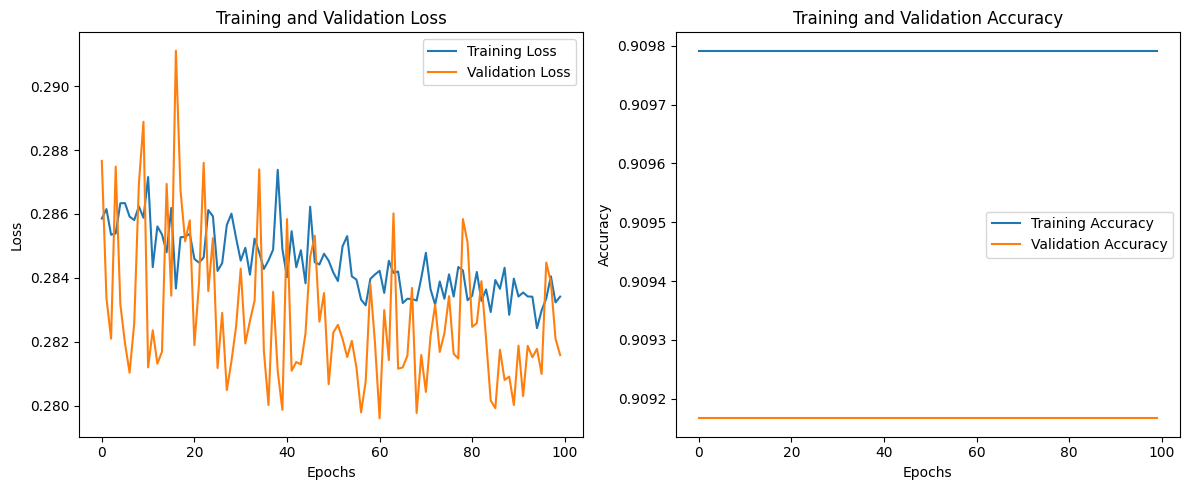

In [ ]:
import matplotlib.pyplot as plt

# Get the training history
history_dict = history.history

# Plot training and validation loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_dict['loss'], label='Training Loss')
plt.plot(history_dict['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history_dict['accuracy'], label='Training Accuracy')
plt.plot(history_dict['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

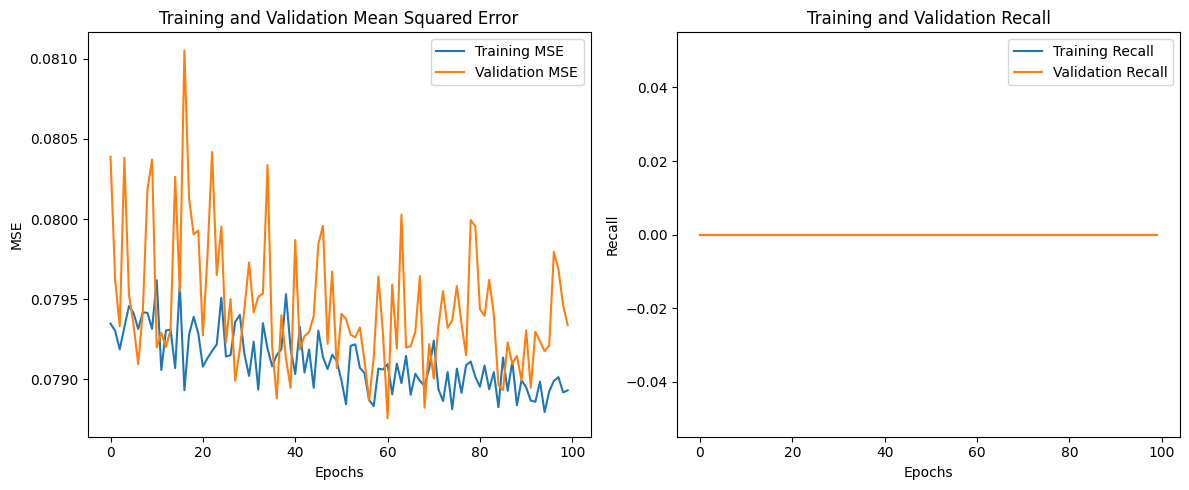

In [ ]:
# Plot training and validation MSE
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_dict['MSE'], label='Training MSE')
plt.plot(history_dict['val_MSE'], label='Validation MSE')
plt.title('Training and Validation Mean Squared Error')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()

# Plot training and validation Recall
plt.subplot(1, 2, 2)
plt.plot(history_dict['recall'], label='Training Recall')
plt.plot(history_dict['val_recall'], label='Validation Recall')
plt.title('Training and Validation Recall')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()

plt.tight_layout()
plt.show()